# Plots for Extended Abstract - OSM Science State of the Map Conference, Paris
**Author:** Eliya Levin

**Contact details:** please mail questions to eliya.levin@mail.huji.ac.il

**Last update:** 10/05/2026

## Setup

### Libraries

In [2]:
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import time
from IPython.display import Markdown
from shapely import wkb
import glob
import sys
import importlib

### Path

In [3]:
current_dir = sys.path[0] # directory path of the notebook
main_dir = os.path.dirname(current_dir) # directory path of the main repository folder

### Link function notebook

In [4]:
# Adding path to system
sys.path.append(main_dir)

In [5]:
# Importing relevant functions
from functions import get_len, get_count, get_area, get_density, wrap_api_query # API call requests
from functions import get_add_from_cum, semi_norm_mix_transform # Method functions
from functions import generate_measure_sample_plot # plotting functions

### Current working method (with log)

In [6]:
# Assess the feature completness measure of some polygon using cumulative feature counts and lengths/areas
def assess_feature_completeness(count_gdf, size_gdf, alpha=0.1, time_thresh=2, saturation_thresh=1.5, abs_thresh=1.5, return_full=False):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative value of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added value (length / area) per each added unit.
    After that, the function applies the following statistical test:
    
    `If all cumulative change percentage is below some alpha (default: 10%) for a stable time period (default: 2 years) without a large absolute addition (default: 150% more than saturation point), the data is considered saturated.`
    
    For supposedly saturated data, the function computes the saturation point (1st month in stable period) and calculates cumulative percentage up to that point.

    The test is verified using 3 conditions:
    (1) No meaningfull relative addition (percentage<`alpha`) for at least `time_thresh` years.
    (2) No absolute addition (count<`abs_thresh`) for at least `time_thresh` years.
    (3) The absolute or relative addition change percentage since the saturation point is less than `saturation_thresh`.

    In all cases, the output is a DataFrame:
    * If not saturated --> the merged DataFrame, with updated timstamps and calculations.
    * If saturated --> can either return only values up to the saturation point + maximum value (default) or return the entire data with reference to the saturation point.
    
    Dependencies:
    * pandas as pd
    '''
    #---------------------------------------------------#
    #                   Data Wrangle                    #
    #---------------------------------------------------#

    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Merge Dataframes
    gdf = count_gdf.copy().rename(columns={'value' : 'count'}) # Copy DF and rename count column
    gdf['size'] = size_gdf['value'] # Append size column

    #---------------------------------------------------#
    #                 Statistical Test                  #
    #---------------------------------------------------#
    
    # Transform values
    gdf['cumulative_percentage'] = gdf['size'] / gdf['count']
    gdf['cumulative_percentage'] = gdf['cumulative_percentage'].fillna(0) # Deal with periods without addition
    gdf['normalized_cum_per'] = gdf['cumulative_percentage'] / gdf['cumulative_percentage'].max()

    # Adjust alpha value for small to large mapping case
    if gdf['cumulative_percentage'].idxmax() >= (len(gdf) * 0.75):
        alpha = 1 - alpha

    # Apply completeness test for level alpha
    gdf['test'] = (gdf['normalized_cum_per'] < alpha) # Boolean term for each date in data

    #---------------------------------------------------#
    #                   Condititon 1                    #
    #---------------------------------------------------#

    # Iterate backwards in data to find stability period
    i = -1 # Running index (from end)
    test = gdf['test'].iat[i] # Running boolean test answer (from end)
    while test:
        try: # Update index
            i -= 1
            test = gdf['test'].iat[i]
        
        except IndexError: # Break loop if at first index
            break
    
    if i == -1:
        # Deal with last value percentage being greater than alpha (i.e. no stable period)
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'no stable period'
            }

    stable = gdf.iloc[i+1:].copy() # Extract stable period

    ## If stable period shorter than given time threshold --> data is incomplete
    if (stable['timestamp'].max() - stable['timestamp'].min()) < pd.Timedelta(days=time_thresh*365):
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'stable period shorter than threshold'
            }
    
    #---------------------------------------------------#
    #             Condititon 3 - 1st phase              #
    #---------------------------------------------------#

    else:
        # Extract saturated value
        saturation_point = stable.iloc[0]

        # Calculate saturation levels
        gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
        
         # Extract emprical maximal value
        real_max = gdf.iloc[-1]
      

        # Check first if data converged. If not, verify if almost converged after one-time event (if exists).
        # Test condition 3 for relative change:
        if (real_max['percentage_until_saturation'] >= saturation_thresh):

    #---------------------------------------------------#
    #                   Condititon 2                    #
    #---------------------------------------------------#

            stable['count_change'] = stable['count'] / stable['count'].max() # Calculate absolute change
            if (stable['count_change'] >= abs_thresh).any():
                # There exists some one-time addition event after saturation
                abs_add_index = stable['count_change'].idxmax()
                if (stable['timestamp'].max() - stable.loc[abs_add_index, 'timestamp']) < pd.Timedelta(days=time_thresh*365):
                    # No stable period since one-time addition event 
                    print('Data incomplete: no stable absolute addition period')
    
    #---------------------------------------------------#
    #             Condititon 3 - 2nd phase              #
    #---------------------------------------------------#

                # Redefine saturation point and levels for one-time addition event
                saturation_point = stable.iloc[abs_add_index]
                gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
                real_max = gdf.iloc[-1]
                
                # Test condition 3 for absoulte change:
                if (real_max['percentage_until_saturation'] >= saturation_thresh):
                    return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable absolute addition larger than threshold'
                        }

            
            else:
                return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable relative addition larger than threshold'
                        }
    
    #---------------------------------------------------#
    #             Output Saturated Results              #
    #---------------------------------------------------#

        # Extract 80% saturation timestamp
        saturated_time = gdf[gdf['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]

        ### Return entire gdf if requested
        if return_full:
            return {
                    'result': gdf,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }
        
        ### Return compact gdf (default)
        else:
            # Filter data until saturation
            saturated = gdf.iloc[:i+1].copy()
        
            # Concatenate empirical maximal value
            saturated = pd.concat([saturated,
                                   pd.DataFrame([real_max])],
                                   ignore_index=True)       
            return {
                    'result': saturated,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }

## Data setup (EDA)

### Import extracted data from Ohsome API

In [7]:
# Import building data
bld_areas = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\building_areas.csv")
bld_counts = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\building_counts.csv")

In [8]:
# Import road data
road_lengths = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\road_lengths.csv")
road_counts = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\road_counts.csv")

In [9]:
# Import events metadata (percentage + bbox)
samp = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\events_sample_df.csv")

In [10]:
# Import new areas for validity data
road_counts_val = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\0. quality measures\1. Feature Completeness\1) Data\3) validity\road_counts_new_areas.csv')
road_lengths_val = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\0. quality measures\1. Feature Completeness\1) Data\3) validity\road_lengths_new_areas.csv')
bld_counts_val = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\0. quality measures\1. Feature Completeness\1) Data\3) validity\building_counts_new_areas.csv')
bld_areas_val = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\0. quality measures\1. Feature Completeness\1) Data\3) validity\building_areas_new_areas.csv')

### Import events shapefile for area and map plot

In [11]:
# upload sample file for mask
events = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\events_sample_df.csv")

In [12]:
# Re-read the geodataframe for crs conversion
gdf = gpd.read_file(r"H:\.shortcut-targets-by-id\1vC82Zl3hhtFy63TpICgdDiHqTHm5dv0h\OSM Projects\Data\Large-scale events\event_weights_grid.shp")

In [13]:
# Arrange data
gdf = gdf.rename(columns={
    'events_w_1' : 'local_knowledge',
    'events_w_2' : 'tag_import',
    'events_w_3' : 'remote_event',
    'events_w_4' : 'late_import',
    'events_w_5' : 'geometry_import',
    'events_w_6' : 'weight_sum',
    'events_wei' : 'early_import'
})

In [14]:
# Extract bounding box coordinates for mask
gdf[['minx', 'miny', 'maxx', 'maxy']] = gdf.bounds
gdf['bbox'] = gdf.apply(
    lambda row: f"{row['minx']},{row['miny']},{row['maxx']},{row['maxy']}",
    axis=1
)
gdf = gdf.drop(columns=['minx', 'miny', 'maxx', 'maxy']) # Drop intermediate columns

In [15]:
# Remove irrelevant columns that aren't in the sampled data
gdf = gdf[gdf['bbox'].isin(events['bbox'])]

In [16]:
# Countries polygon dataset (as basemap)
countries = gpd.read_file(r"H:\.shortcut-targets-by-id\1vC82Zl3hhtFy63TpICgdDiHqTHm5dv0h\OSM Projects\Data\countries_polygons\World_Countries.geojson")

### Assess completeness using method

In [17]:
# Assess feature completeness for buildings
bld_tests = []

for idx, count_group in bld_counts.groupby('idx'):
    area_group = bld_areas[bld_areas['idx'] == idx].copy() # grouping area dataframe entries
    
    res = assess_feature_completeness(count_group, area_group, return_full=True) # Apply method
    
    # Preserve original event metadata:
    res['idx'] = idx
    res['event_type'] = count_group['event_type'].iloc[0]
    res['event_percentage'] = count_group['event_percentage'].iloc[0]
    if res['event_percentage'] == samp.iloc[idx]['event_percentage']: # verify match before adding bbox
        res['bbox'] = samp.iloc[idx]['bbox']
    else:
        print(f"Warning: event percentage mismatch for idx {idx}. Check data consistency.")
        break

    bld_tests.append(res)

In [18]:
# Assess feature completeness for roads
road_tests = []

for idx, count_group in road_counts.groupby('idx'):
    len_group = road_lengths[road_lengths['idx'] == idx].copy() # grouping length dataframe entries
    
    res = assess_feature_completeness(count_group, len_group, return_full=True) # Apply method
    
    # Preserve original event metadata:
    res['idx'] = idx
    res['event_type'] = count_group['event_type'].iloc[0]
    res['event_percentage'] = count_group['event_percentage'].iloc[0]
    if res['event_percentage'] == samp.iloc[idx]['event_percentage']: # verify match before adding bbox
        res['bbox'] = samp.iloc[idx]['bbox']
    else:
        print(f"Warning: event percentage mismatch for idx {idx}. Check data consistency.")
        break

    road_tests.append(res)

In [19]:
# Add results to events gdf for later plotting
bld_df = pd.DataFrame(bld_tests)[['bbox', 'status', 'saturation_point', 'incompletion_reason']].rename(columns={
    'status': 'bld_status',
    'saturation_point': 'bld_saturation_point',
    'incompletion_reason': 'bld_reason'
})
road_df = pd.DataFrame(road_tests)[['bbox', 'status', 'saturation_point', 'incompletion_reason']].rename(columns={
    'status': 'road_status',
    'saturation_point': 'road_saturation_point',
    'incompletion_reason': 'road_reason'
})

gdf = gdf.merge(bld_df, on='bbox', how='left')
gdf = gdf.merge(road_df, on='bbox', how='left')

In [20]:
# Assess feature completeness for buildings - validity dataset
bld_tests_val = []

for idx, count_group in bld_counts_val.groupby('idx'):
    area_group = bld_areas_val[bld_areas_val['idx'] == idx].copy() # grouping area dataframe entries
    
    res = assess_feature_completeness(count_group, area_group, return_full=True) # Apply method
    
    # Preserve original event metadata:
    res['idx'] = idx
    res['place'] = count_group['place'].iloc[0]

    bld_tests_val.append(res)

In [21]:
# Assess feature completeness for roads - validity dataset
road_tests_val = []

for idx, count_group in road_counts_val.groupby('idx'):
    area_group = road_lengths_val[road_lengths_val['idx'] == idx].copy() # grouping area dataframe entries
    
    res = assess_feature_completeness(count_group, area_group, return_full=True) # Apply method
    
    # Preserve original event metadata:
    res['idx'] = idx
    res['place'] = count_group['place'].iloc[0]

    road_tests_val.append(res)

## Panel checks

* No. of complete
* No. of incomplete
* Percentages of each incompletion type

### Building data

In [22]:
bld_status = sum(1 for entry in bld_tests if entry.get('status') == 'complete') # general completeness status for buildings

In [23]:
bld_complete_percentage = round(bld_status / len(bld_tests) * 100, 3) # completeness percentage for buildings

In [24]:
# Completeness status for buildings by event type
bld_complete_by_type = {}
bld_incomplete_by_type = {}

for event_type in samp['event_type'].unique():
    bld_complete_by_type[event_type] = sum(1 for entry in bld_tests if (entry.get('status') == 'complete') and (entry.get('event_type') == event_type))

for event_type in samp['event_type'].unique():
    bld_incomplete_by_type[event_type] = sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == event_type))

In [25]:
# Calculate complete and incomplete counts and percentages for buildings by event type
bld_status_by_type = pd.DataFrame(bld_complete_by_type.items(), columns=['Event type', 'Complete'])
bld_status_by_type['Incomplete'] = bld_status_by_type['Event type'].map(bld_incomplete_by_type)
bld_status_by_type['Sample size (n)'] = bld_status_by_type['Complete'] + bld_status_by_type['Incomplete']
bld_status_by_type['Complete percentage'] = round(bld_status_by_type['Complete'] / bld_status_by_type['Sample size (n)'], 3)
bld_status_by_type['Incomplete percentage'] = round(1 - bld_status_by_type['Complete percentage'], 3)

In [26]:
print("Results:")
print(f"Overall completeness for buildings: {bld_status} out of {len(bld_tests)} events ({bld_complete_percentage}%)")
display(Markdown(bld_status_by_type.to_markdown(index=False)))

Results:
Overall completeness for buildings: 76 out of 446 events (17.04%)


| Event type      |   Complete |   Incomplete |   Sample size (n) |   Complete percentage |   Incomplete percentage |
|:----------------|-----------:|-------------:|------------------:|----------------------:|------------------------:|
| local_knowledge |          4 |           24 |                28 |                 0.143 |                   0.857 |
| remote_event    |         43 |          216 |               259 |                 0.166 |                   0.834 |
| early_import    |         24 |          103 |               127 |                 0.189 |                   0.811 |
| geometry_import |          1 |            7 |                 8 |                 0.125 |                   0.875 |
| tag_import      |          4 |            5 |                 9 |                 0.444 |                   0.556 |
| late_import     |          0 |           15 |                15 |                 0     |                   1     |

#### Validity data

In [27]:
status_val = pd.DataFrame({'Feature type' : ['building', 'road'],
                           'Complete' : [0,0],
                           'Incomplete' : [0,0],
                           'Sample size (n)' : [len(bld_tests_val), len(road_tests_val)]})

In [28]:
status_val.loc[status_val['Feature type'] == 'building', 'Complete'] = sum(1 for entry in bld_tests_val if entry.get('status') == 'complete')
status_val.loc[status_val['Feature type'] == 'building', 'Incomplete'] = sum(1 for entry in bld_tests_val if entry.get('status') == 'incomplete')
status_val.loc[status_val['Feature type'] == 'road', 'Complete'] = sum(1 for entry in road_tests_val if entry.get('status') == 'complete')
status_val.loc[status_val['Feature type'] == 'road', 'Incomplete'] = sum(1 for entry in road_tests_val if entry.get('status') == 'incomplete')

In [29]:
status_val.loc[status_val['Feature type'] == 'building', 'Complete percentage'] = status_val.loc[status_val['Feature type'] == 'building', 'Complete'] / status_val.loc[status_val['Feature type'] == 'building', 'Sample size (n)']
status_val.loc[status_val['Feature type'] == 'building', 'Incomplete percentage'] = status_val.loc[status_val['Feature type'] == 'building', 'Incomplete'] / status_val.loc[status_val['Feature type'] == 'building', 'Sample size (n)']
status_val.loc[status_val['Feature type'] == 'road', 'Complete percentage'] = status_val.loc[status_val['Feature type'] == 'road', 'Complete'] / status_val.loc[status_val['Feature type'] == 'road', 'Sample size (n)']
status_val.loc[status_val['Feature type'] == 'road', 'Incomplete percentage'] = status_val.loc[status_val['Feature type'] == 'road', 'Incomplete'] / status_val.loc[status_val['Feature type'] == 'road', 'Sample size (n)']

In [30]:
bld_incompletion_reasons = [entry.get('incompletion_reason') for entry in bld_tests_val]
road_incompletion_reasons = [entry.get('incompletion_reason') for entry in road_tests_val]

In [31]:
status_val.loc[status_val['Feature type'] == 'building', 'No stable period'] = int(sum(1 for x in bld_incompletion_reasons if x == 'no stable period'))
status_val.loc[status_val['Feature type'] == 'building', 'Consistent relative addition'] = int(sum(1 for x in bld_incompletion_reasons if x == 'stable relative addition larger than threshold'))
status_val.loc[status_val['Feature type'] == 'road', 'No stable period'] = int(sum(1 for x in road_incompletion_reasons if x == 'no stable period'))
status_val.loc[status_val['Feature type'] == 'road', 'Consistent relative addition'] = int(sum(1 for x in road_incompletion_reasons if x == 'stable relative addition larger than threshold'))

In [32]:
status_val['Small stable period'] = [0,0]
status_val['Consistent absolute addition'] = [0,0]

In [33]:
status_val

,Feature type,Complete,Incomplete,Sample size (n),Complete percentage,Incomplete percentage,No stable period,Consistent relative addition,Small stable period,Consistent absolute addition
0,building,0,17,17,0.0,1.0,2.0,15.0,0,0
1,road,0,17,17,0.0,1.0,13.0,4.0,0,0


### Road data

In [34]:
road_status = sum(1 for entry in road_tests if entry.get('status') == 'complete') # general completeness status for roads

In [35]:
road_complete_percentage = round(road_status / len(road_tests) * 100, 3) # completeness percentage for roads

In [36]:
# Completeness status for roads by event type
road_complete_by_type = {}
road_incomplete_by_type = {}

for event_type in samp['event_type'].unique():
    road_complete_by_type[event_type] = sum(1 for entry in road_tests if (entry.get('status') == 'complete') and (entry.get('event_type') == event_type))

for event_type in samp['event_type'].unique():
    road_incomplete_by_type[event_type] = sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == event_type))

In [37]:
# Calculate complete and incomplete counts and percentages for buildings by event type
road_status_by_type = pd.DataFrame(road_complete_by_type.items(), columns=['Event type', 'Complete'])
road_status_by_type['Incomplete'] = road_status_by_type['Event type'].map(road_incomplete_by_type)
road_status_by_type['Sample size (n)'] = road_status_by_type['Complete'] + road_status_by_type['Incomplete']
road_status_by_type['Complete percentage'] = round(road_status_by_type['Complete'] / road_status_by_type['Sample size (n)'], 3)
road_status_by_type['Incomplete percentage'] = round(1 - road_status_by_type['Complete percentage'], 3)

In [38]:
print("Results:")
print(f"Overall completeness for roads: {road_status} out of {len(road_tests)} events ({road_complete_percentage}%)")
display(Markdown(road_status_by_type.to_markdown(index=False)))

Results:
Overall completeness for roads: 35 out of 446 events (7.848%)


| Event type      |   Complete |   Incomplete |   Sample size (n) |   Complete percentage |   Incomplete percentage |
|:----------------|-----------:|-------------:|------------------:|----------------------:|------------------------:|
| local_knowledge |          1 |           27 |                28 |                 0.036 |                   0.964 |
| remote_event    |         22 |          237 |               259 |                 0.085 |                   0.915 |
| early_import    |         11 |          116 |               127 |                 0.087 |                   0.913 |
| geometry_import |          0 |            8 |                 8 |                 0     |                   1     |
| tag_import      |          0 |            9 |                 9 |                 0     |                   1     |
| late_import     |          1 |           14 |                15 |                 0.067 |                   0.933 |

## Distributions

### Pre-processing

In [39]:
# Add incompletion reason per each event (building data)
bld_status_by_type['No stable period'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'no stable period')))
bld_status_by_type['Small stable period'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable period shorter than threshold')))
bld_status_by_type['Consistent absolute addition'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable absolute addition larger than threshold')))
bld_status_by_type['Consistent relative addition'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable relative addition larger than threshold')))

In [40]:
# Add incompletion reason per each event (road data)
road_status_by_type['No stable period'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'no stable period')))
road_status_by_type['Small stable period'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable period shorter than threshold')))
road_status_by_type['Consistent absolute addition'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable absolute addition larger than threshold')))
road_status_by_type['Consistent relative addition'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable relative addition larger than threshold')))

In [41]:
# reason list and label map for easier data map
reasons = ['No stable period', 'Small stable period', 'Consistent absolute addition', 'Consistent relative addition'] # list for easier mapping
label_map = {
    'local_knowledge': 'Local Knowledge',
    'remote_event': 'Remote Event',
    'early_import': 'Early Import',
    'geometry_import': 'Geometry Import',
    'tag_import': 'Tag Import',
    'late_import': 'Late Import'
}

In [42]:
# Add incompletion reason per each event (building data)
bld_status_by_type['No stable period'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'no stable period')))
bld_status_by_type['Small stable period'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable period shorter than threshold')))
bld_status_by_type['Consistent absolute addition'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable absolute addition larger than threshold')))
bld_status_by_type['Consistent relative addition'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable relative addition larger than threshold')))

In [43]:
bld_status_by_type_val = pd.DataFrame(road_complete_by_type.items(), columns=['Event type', 'Complete'])
road_status_by_type['Incomplete'] = road_status_by_type['Event type'].map(road_incomplete_by_type)
road_status_by_type['Sample size (n)'] = road_status_by_type['Complete'] + road_status_by_type['Incomplete']
road_status_by_type['Complete percentage'] = round(road_status_by_type['Complete'] / road_status_by_type['Sample size (n)'], 3)
road_status_by_type['Incomplete percentage'] = round(1 - road_status_by_type['Complete percentage'], 3)

### Incompletion Ratios by Reason

In [44]:
#  General bar plot of incompletion reasons by event dataset
bld_status_by_type_sum = bld_status_by_type[['Incomplete'] + reasons].sum().to_frame().T # generate general statistics for all building dataset
road_status_by_type_sum = road_status_by_type[['Incomplete'] + reasons].sum().to_frame().T # generate general statistics for all road dataset

# Calculate proportions
bld_status_by_type_sum[reasons] = round(bld_status_by_type_sum[reasons] / bld_status_by_type_sum['Incomplete'].iloc[0], 4)
road_status_by_type_sum[reasons] = round(road_status_by_type_sum[reasons] / road_status_by_type_sum['Incomplete'].iloc[0], 4)

In [45]:
status_val[reasons] = status_val[reasons].div(status_val['Incomplete'], axis=0).round(4)

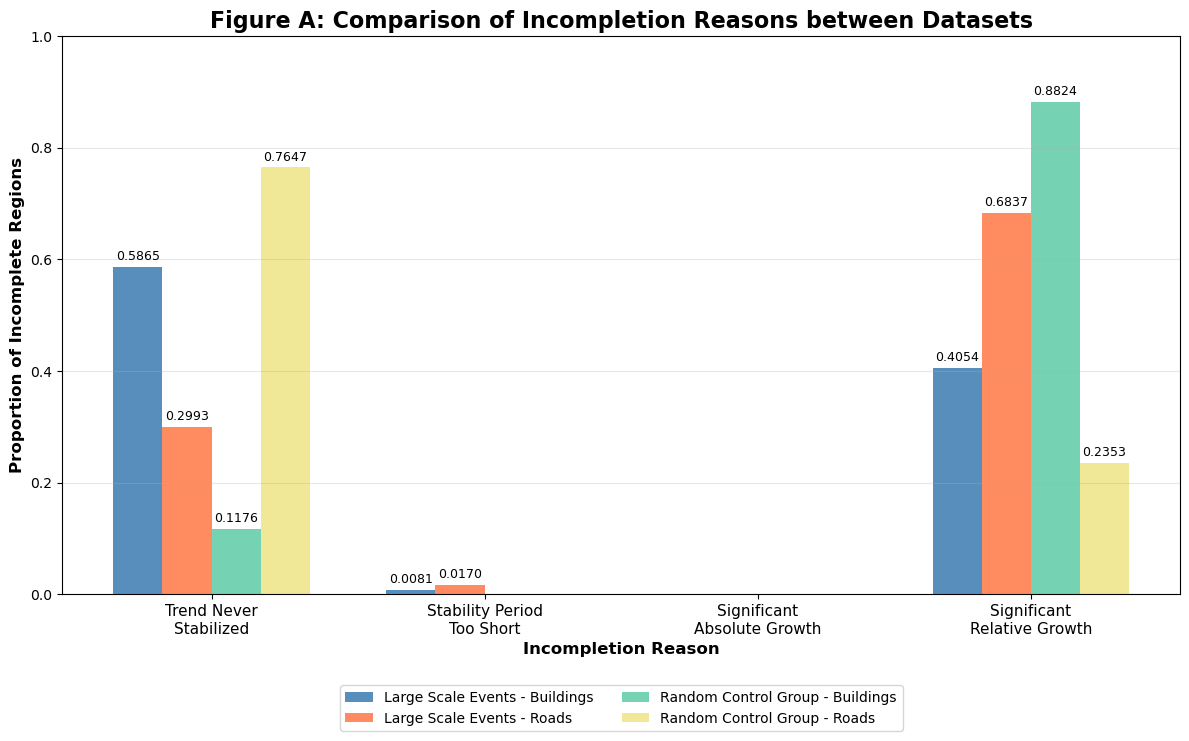

In [46]:
# Prepare data for plotting
bld_plot = bld_status_by_type_sum[reasons].iloc[0].to_frame().T.copy()
bld_plot['Data'] = 'Large Scale Events - Buildings'

road_plot = road_status_by_type_sum[reasons].iloc[0].to_frame().T.copy()
road_plot['Data'] = 'Large Scale Events - Roads'

bld_val_plot = status_val[reasons].iloc[0].to_frame().T.copy()
bld_val_plot['Data'] = 'Random Control Group - Buildings'

road_val_plot = status_val[reasons].iloc[1].to_frame().T.copy()
road_val_plot['Data'] = 'Random Control Group - Roads'

# Combine and melt to long format
plot_data = pd.concat([bld_plot, road_plot, bld_val_plot, road_val_plot], ignore_index=True)
plot_data = plot_data.melt(id_vars=['Data'], var_name='Reason', value_name='Proportion')

# Create histogram-style bar plot
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique reasons and datasets
reasons_list = plot_data['Reason'].unique()
datasets = ['Large Scale Events - Buildings', 'Large Scale Events - Roads', 'Random Control Group - Buildings', 'Random Control Group - Roads']
bar_width = 0.18
x_pos = np.arange(len(reasons_list))

# Create bars for each dataset
colors = ['steelblue', 'coral', 'mediumaquamarine', 'khaki']
for i, dataset in enumerate(datasets):
    data_subset = plot_data[plot_data['Data'] == dataset]
    values = [data_subset[data_subset['Reason'] == reason]['Proportion'].values[0] if any(data_subset['Reason'] == reason) else 0 for reason in reasons_list]
    offset = (i - 1.5) * bar_width
    bars = ax.bar(x_pos + offset, values, bar_width, label=dataset, alpha=0.9, color=colors[i])
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

# Rename reasons for cleaner labels
reason_map = {
    'No stable period': 'Trend Never\nStabilized',
    'Consistent relative addition': 'Significant\nRelative Growth',
    'Small stable period': 'Stability Period\nToo Short',
    'Consistent absolute addition': 'Significant\nAbsolute Growth'
}

# Set labels and formatting
ax.set_xlabel('Incompletion Reason', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion of Incomplete Regions', fontsize=12, fontweight='bold')
ax.set_title('Figure A: Comparison of Incompletion Reasons between Datasets', 
             fontsize=16, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_xticks(x_pos)
ax.set_xticklabels([reason_map.get(r, r) for r in reasons_list], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# # Add incompletion counts as text label in top left
# bld_incomplete = bld_status_by_type_sum['Incomplete'].iloc[0]
# road_incomplete = road_status_by_type_sum['Incomplete'].iloc[0]
# bld_val_incomplete = status_val.loc[status_val['Feature type'] == 'building', 'Incomplete'].iat[0]
# road_val_incomplete = status_val.loc[status_val['Feature type'] == 'road', 'Incomplete'].iat[0]
# incompletion_text = (
#     r"$\bf{Total\ incomplete\ regions\ in\ datasets:}$" + "\n"
#     f'Large Scale Events building dataset: {int(bld_incomplete)}, {int(bld_incomplete) / 446 * 100:.2f}% from entire dataset\n'
#     f'Large Scale Events road dataset: {int(road_incomplete)}, {int(road_incomplete) / 446 * 100:.2f}% from entire dataset\n'
#     f'Random Control Group (Validity Test), building and road datasets: {int(bld_val_incomplete)}, 100% from entire dataset'
# )

# ax.text(0.01, 0.99, incompletion_text, transform=ax.transAxes,
#         fontsize=10, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend(fontsize=10, title_fontsize=11,
          loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

#### Event Type only

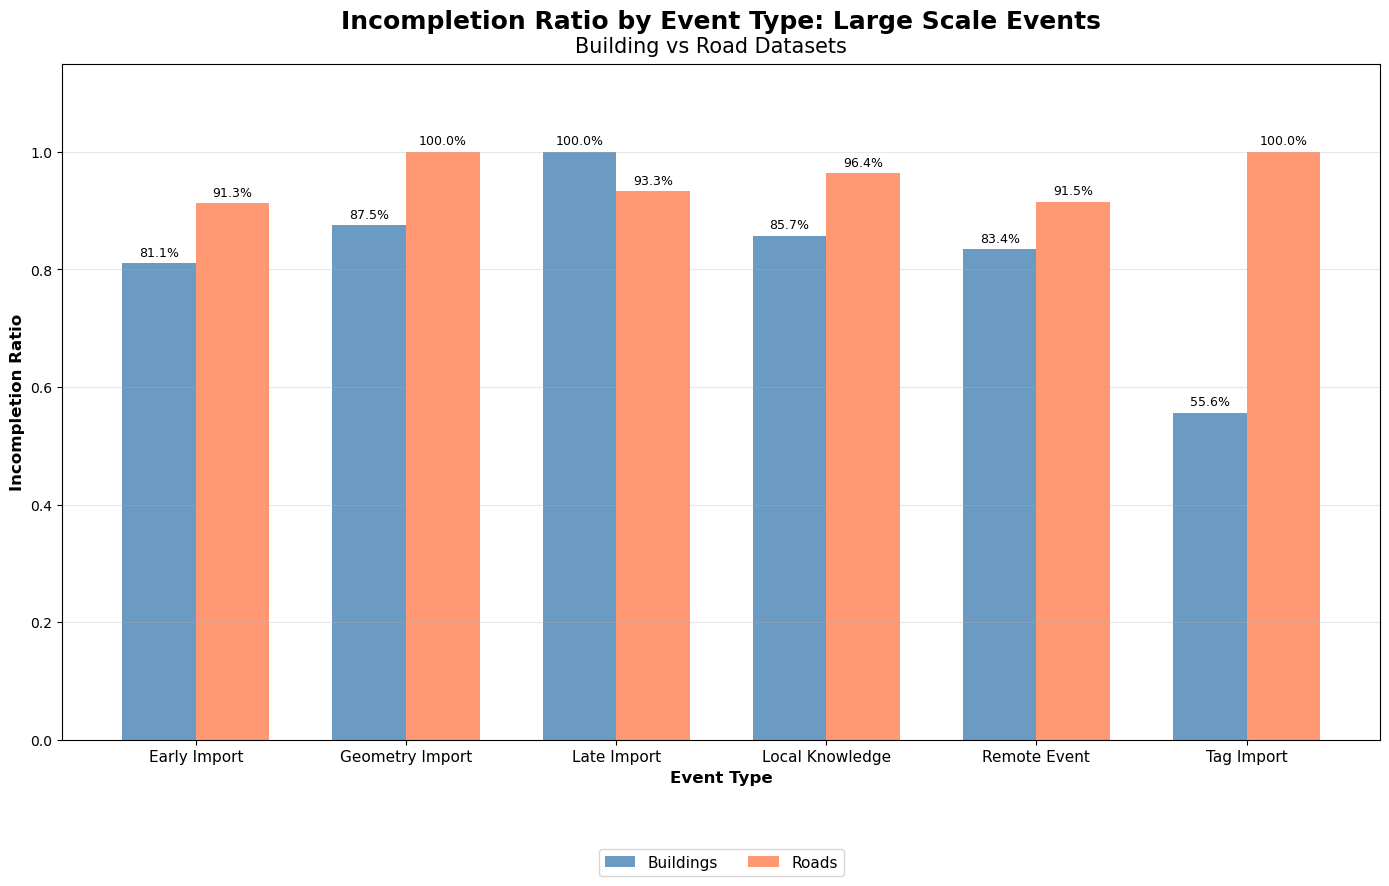

In [47]:
# Prepare data for plotting by event type
# Rename events for cleaner plot labels
bld_plot_data = bld_status_by_type.copy()
road_plot_data = road_status_by_type.copy()

bld_plot_data['Event type'] = bld_plot_data['Event type'].replace(label_map)
road_plot_data['Event type'] = road_plot_data['Event type'].replace(label_map)

# Create combined dataframe for plotting
plot_by_event = pd.concat([
    bld_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Buildings'),
    road_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Roads')
], ignore_index=True)

# Create histogram-style bar plot
fig, ax = plt.subplots(figsize=(14, 9))

# Get unique event types
event_types = sorted(bld_plot_data['Event type'].unique())
datasets = ['Buildings', 'Roads']
bar_width = 0.35
x_pos = np.arange(len(event_types))

# Create bars for each dataset
colors = ['steelblue', 'coral']
for i, dataset in enumerate(datasets):
    data_subset = plot_by_event[plot_by_event['Dataset'] == dataset]
    values = [data_subset[data_subset['Event type'] == event]['Incomplete percentage'].values[0] if any(data_subset['Event type'] == event) else 0 for event in event_types]
    offset = (i - 0.5) * bar_width
    bars = ax.bar(x_pos + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1%}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

# Set labels and formatting
ax.set_xlabel('Event Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Incompletion Ratio', fontsize=12, fontweight='bold')
ax.set_title('Incompletion Ratio by Event Type: Large Scale Events', 
             fontsize=18, fontweight='bold', y=1.04)
ax.text(s='Building vs Road Datasets', fontsize=15, x=2.45, y=1.17, ha='center')
ax.set_ylim(0, 1.15)
ax.set_xticks(x_pos)
ax.set_xticklabels(event_types, fontsize=11, ha='center')
ax.legend(fontsize=11, title_fontsize=12,
          loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Event Type & Reason

#### Conclusions

When looking at the trends more closely, we can see charcteristics of events incomplete mapping in roads according to the method. If it's correct, this means that it might help decipher different mapping results, such as the fact that tag import events had more incomplete areas due to no stability period, as opposed to ocal knowledge due mostly to a significant relative growth. 

This means that if we assume the method works well, it uncovers different incomplete mapping results according to mapping culture attributes, which can be a very interesting discovery.

### By extent (bbox) size

#### Calculate area per each event polygon

In [48]:
gdf.to_crs(epsg=8857, inplace=True) # change crs to WGS84 / equal earth for accurate metric area calculation

In [49]:
gdf['area'] = gdf['geometry'].area # calculate area in square meters for each grid cell

#### Append to test data

In [50]:
# Create a string-keyed area lookup from gdf
area_lookup = {str(bbox): area for bbox, area in zip(gdf['bbox'], gdf['area'])}

# Apply rowwise lookup
bld_tests = [{**row, 'area': area_lookup.get(str(row['bbox']), np.nan)} for row in bld_tests]
road_tests = [{**row, 'area': area_lookup.get(str(row['bbox']), np.nan)} for row in road_tests]

In [51]:
# Create simple DF for analysis
road_status_by_area = pd.DataFrame(road_tests)[['area', 'status', 'saturation_point', 'incompletion_reason', 'idx', 'event_type']].copy()
bld_status_by_area = pd.DataFrame(bld_tests)[['area', 'status', 'saturation_point', 'incompletion_reason', 'idx', 'event_type']].copy()

In [52]:
# Convert area to square kilometers for easier interpretation
road_status_by_area['area_sqkm'] = round(road_status_by_area['area'] / 1000, 3)
bld_status_by_area['area_sqkm'] = round(bld_status_by_area['area'] / 1000, 3)

In [53]:
# Explanation snippet for filtering:
std = round(np.var(road_status_by_area['area_sqkm'])**0.5, 2)

display(Markdown(f"""
Because the variance of the area values is so big ($\\sigma = {std}$), 
we'll filter out outliers from the datasets.
"""))


Because the variance of the area values is so big ($\sigma = 73406558.41$), 
we'll filter out outliers from the datasets.


In [54]:
# Filtering out the data
Q1 = road_status_by_area['area_sqkm'].quantile(0.25)
Q3 = road_status_by_area['area_sqkm'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 2 * IQR
upper = Q3 + 2 * IQR

# Filter outliers out
filtered_road_status_by_area = road_status_by_area[
    (road_status_by_area['area_sqkm'] >= lower) & 
    (road_status_by_area['area_sqkm'] <= upper)
]

filtered_bld_status_by_area = bld_status_by_area[
    (bld_status_by_area['area_sqkm'] >= lower) & 
    (bld_status_by_area['area_sqkm'] <= upper)
]

# Print new data shapes:
print('Original datasets\nRoads:')
print(f"  Shape: {road_status_by_area.shape}")
print(f"  No. of complete features: {road_status_by_area[road_status_by_area['status'] == 'complete'].shape[0]}")
print('Buildings:')
print(f"  Shape: {bld_status_by_area.shape}")
print(f"No. of complete features: {bld_status_by_area[bld_status_by_area['status'] == 'complete'].shape[0]}\n")

print('Filtered datasets\nRoads:')
print(f"  Shape: {filtered_road_status_by_area.shape}")
print(f"  No. of complete features: {filtered_road_status_by_area[filtered_road_status_by_area['status'] == 'complete'].shape[0]}")
print('Buildings:')
print(f"  Shape: {filtered_bld_status_by_area.shape}")
print(f"  No. of complete features: {filtered_bld_status_by_area[filtered_bld_status_by_area['status'] == 'complete'].shape[0]}\n")

Original datasets
Roads:
  Shape: (446, 7)
  No. of complete features: 35
Buildings:
  Shape: (446, 7)
No. of complete features: 76

Filtered datasets
Roads:
  Shape: (381, 7)
  No. of complete features: 31
Buildings:
  Shape: (381, 7)
  No. of complete features: 68



Note: because using the formula of $1.5 \times IQR$ amounted to removing a quarter of the data (about 100 entries were considered outliers) I decided to be less constrictive and regard only entries which are beyond the benchmark of  $2 \times IQR$ - that, while they amount to a quarter of the data..

#### General Distribution of areas

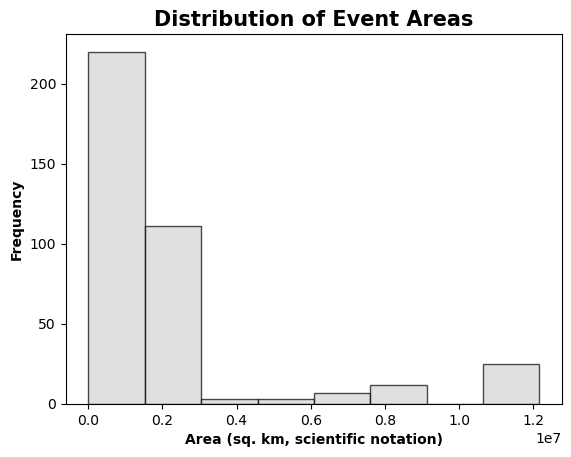

Minimum area: 7924.186
Maximum area: 12165114.694


In [55]:
filtered_road_status_by_area['area_sqkm'].plot.hist(
    bins=8, 
    color='lightgrey', 
    alpha=0.7, 
    edgecolor='black')
plt.xlabel('Area (sq. km, scientific notation)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of Event Areas', fontsize=15, fontweight='bold')
plt.show()

print(f'Minimum area: {filtered_road_status_by_area["area_sqkm"].min()}')
print(f'Maximum area: {filtered_road_status_by_area["area_sqkm"].max()}')

We can see the variation of area with the large gap and bin width above.

#### Distribution of Incompletion by area bins

In [56]:
# Bin the area values into 8 equal-width bins for further analysis
filtered_road_status_by_area = filtered_road_status_by_area.copy()
filtered_road_status_by_area['area_sqkm'] = filtered_road_status_by_area['area_sqkm'].clip(lower=0)

filtered_bld_status_by_area = filtered_bld_status_by_area.copy()
filtered_bld_status_by_area['area_sqkm'] = filtered_bld_status_by_area['area_sqkm'].clip(lower=0)

max_area = max(filtered_road_status_by_area['area_sqkm'].max(), filtered_bld_status_by_area['area_sqkm'].max())
area_bin_edges = np.linspace(0, max_area, 9)

filtered_road_status_by_area['area_bin'] = pd.cut(filtered_road_status_by_area['area_sqkm'], bins=area_bin_edges, include_lowest=True)
filtered_bld_status_by_area['area_bin'] = pd.cut(filtered_bld_status_by_area['area_sqkm'], bins=area_bin_edges, include_lowest=True)

In [57]:
# Generate completion statistics by area bin
filtered_road_sum_by_area = filtered_road_status_by_area.groupby('area_bin', observed=True).agg(
    Complete=('status', lambda x: (x == 'complete').sum()),
    Incomplete=('status', lambda x: (x == 'incomplete').sum()),
    Sample_size=('area_sqkm', 'count'),
    complete_percentage=('status', lambda x: (x == 'complete').mean().round(3)),
    incomplete_percentage=('status', lambda x: (x == 'incomplete').mean().round(3)),
    no_stable_period=('incompletion_reason', lambda x: (x == 'no stable period').sum()),
    small_stable_period=('incompletion_reason', lambda x: (x == 'stable period shorter than threshold').sum()),
    stable_absolute_addition=('incompletion_reason', lambda x: (x == 'stable absolute addition larger than threshold').sum()),
    stable_relative_addition=('incompletion_reason', lambda x: (x == 'stable relative addition larger than threshold').sum())
).reset_index()

filtered_road_sum_by_area.rename(columns={
    'area_bin': 'Area bin',
    'Sample_size': 'Sample size (n)',
    'complete_percentage': 'Complete percentage',
    'incomplete_percentage': 'Incomplete percentage',
    'no_stable_period': 'No stable period',
    'small_stable_period': 'Small stable period',
    'stable_absolute_addition': 'Stable absolute addition',
    'stable_relative_addition': 'Stable relative addition'
}, inplace=True)

In [58]:
# Generate completion statistics by area bin
filtered_bld_sum_by_area = filtered_bld_status_by_area.groupby('area_bin', observed=True).agg(
    Complete=('status', lambda x: (x == 'complete').sum()),
    Incomplete=('status', lambda x: (x == 'incomplete').sum()),
    Sample_size=('area_sqkm', 'count'),
    complete_percentage=('status', lambda x: (x == 'complete').mean().round(3)),
    incomplete_percentage=('status', lambda x: (x == 'incomplete').mean().round(3)),
    no_stable_period=('incompletion_reason', lambda x: (x == 'no stable period').sum()),
    small_stable_period=('incompletion_reason', lambda x: (x == 'stable period shorter than threshold').sum()),
    stable_absolute_addition=('incompletion_reason', lambda x: (x == 'stable absolute addition larger than threshold').sum()),
    stable_relative_addition=('incompletion_reason', lambda x: (x == 'stable relative addition larger than threshold').sum())
).reset_index()

filtered_bld_sum_by_area.rename(columns={
    'area_bin': 'Area bin',
    'Sample_size': 'Sample size (n)',
    'complete_percentage': 'Complete percentage',
    'incomplete_percentage': 'Incomplete percentage',
    'no_stable_period': 'No stable period',
    'small_stable_period': 'Small stable period',
    'stable_absolute_addition': 'Stable absolute addition',
    'stable_relative_addition': 'Stable relative addition'
}, inplace=True)

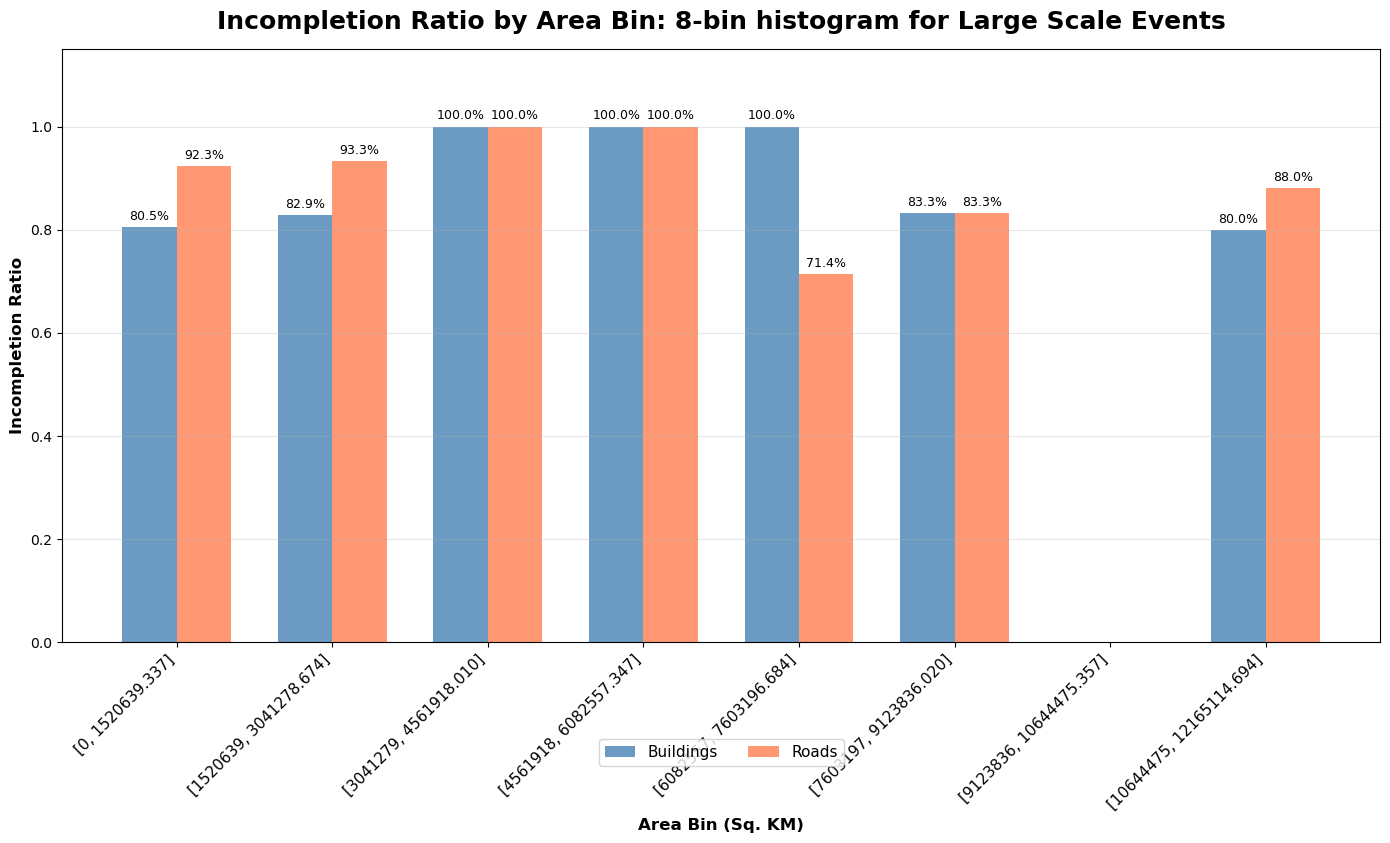

In [59]:
# Prepare data for plotting by area bin
plot_by_area = pd.concat([
    filtered_bld_sum_by_area[['Area bin', 'Incomplete percentage']].assign(Dataset='Buildings'),
    filtered_road_sum_by_area[['Area bin', 'Incomplete percentage']].assign(Dataset='Roads')
], ignore_index=True)

# Create histogram-style bar plot
fig, ax = plt.subplots(figsize=(14, 9))

# Get unique area bins
area_bins = list(filtered_road_sum_by_area['Area bin'].cat.categories)
datasets = ['Buildings', 'Roads']
bar_width = 0.35
x_pos = np.arange(len(area_bins))

# Create bars for each dataset
colors = ['steelblue', 'coral']
for i, dataset in enumerate(datasets):
    data_subset = plot_by_area[plot_by_area['Dataset'] == dataset]
    values = [data_subset.loc[data_subset['Area bin'] == bin, 'Incomplete percentage'].values[0] if any(data_subset['Area bin'] == bin) else 0 for bin in area_bins]
    offset = (i - 0.5) * bar_width
    bars = ax.bar(x_pos + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1%}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=9)

# Build explicit area bin labels and fix the first bin label to start at 0
area_labels = []
for idx, bin in enumerate(area_bins):
    left = 0 if idx == 0 else bin.left
    right = bin.right
    area_labels.append(f'[{left:.0f}, {right:.3f}]')

# Set labels and formatting
ax.set_xlabel('Area Bin (Sq. KM)', fontsize=12, fontweight='bold')
ax.set_ylabel('Incompletion Ratio', fontsize=12, fontweight='bold')
ax.set_title('Incompletion Ratio by Area Bin: 8-bin histogram for Large Scale Events', 
             fontsize=18, fontweight='bold', y=1.02)
ax.set_ylim(0, 1.15)
ax.set_xticks(x_pos)
ax.set_xticklabels(area_labels, fontsize=11, rotation=45, ha='right')
ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


### Final plot B

In [84]:
# Prepare data for plotting by event type
# Rename events for cleaner plot labels
bld_plot_data = bld_status_by_type.copy()
road_plot_data = road_status_by_type.copy()

bld_plot_data['Event type'] = bld_plot_data['Event type'].replace(label_map)
road_plot_data['Event type'] = road_plot_data['Event type'].replace(label_map)

# Create combined dataframe for plotting
plot_by_event = pd.concat([
    bld_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Buildings'),
    road_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Roads')
], ignore_index=True)

# Keep event type categories for the faceted plot
event_types = sorted(bld_plot_data['Event type'].unique())
x_pos_1 = np.arange(len(event_types))

In [85]:
# Prepare data for plotting by area bins
plot_by_area = pd.concat([
    filtered_bld_sum_by_area[['Area bin', 'Incomplete percentage']].assign(Dataset='Buildings'),
    filtered_road_sum_by_area[['Area bin', 'Incomplete percentage']].assign(Dataset='Roads')
], ignore_index=True)

# # Fix first interval label
# plot_by_area['Area bin'] = plot_by_area['Area bin'].cat.rename_categories(
#     {plot_by_area['Area bin'][0]: pd.Interval(0, plot_by_area['Area bin'][0].right, closed='right')}
# )

area_bins = list(filtered_road_sum_by_area['Area bin'].cat.categories)
x_pos_2 = np.arange(len(area_bins))

In [86]:
# General design parameters for both plots
colors = ['steelblue', 'coral']
datasets = ['Buildings', 'Roads']
legend_entries = ['Building Dataset', 'Road Dataset']
bar_width = 0.35

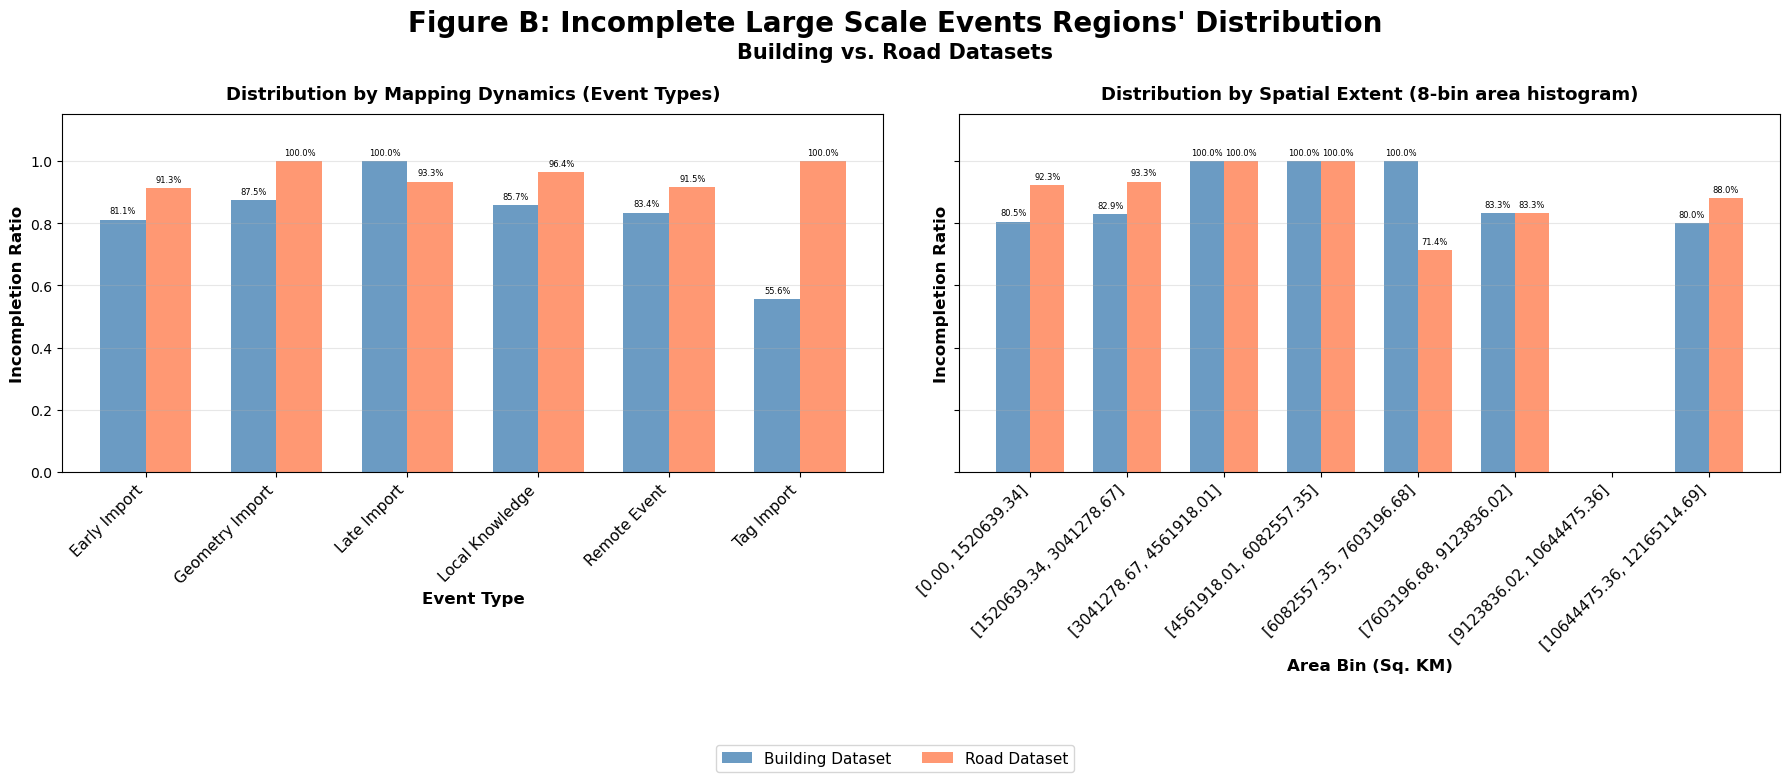

In [124]:
# Plot B
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot event types
for i, dataset in enumerate(datasets):
    data_subset = plot_by_event[plot_by_event['Dataset'] == dataset]
    values = [data_subset[data_subset['Event type'] == event]['Incomplete percentage'].values[0] if any(data_subset['Event type'] == event) else 0 for event in event_types]
    offset = (i - 0.5) * bar_width
    bars = axes[0].bar(x_pos_1 + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0].annotate(f'{height:.1%}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=6)

# Set labels and formatting
axes[0].set_xlabel('Event Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Incompletion Ratio', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution by Mapping Dynamics (Event Types)', fontsize=13, fontweight='bold', y=1.02)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x_pos_1)
axes[0].set_xticklabels(event_types, rotation=45, fontsize=11, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot area bins
for i, dataset in enumerate(datasets):
    data_subset = plot_by_area[plot_by_area['Dataset'] == dataset]
    values = [data_subset.loc[data_subset['Area bin'] == bin, 'Incomplete percentage'].values[0] if any(data_subset['Area bin'] == bin) else 0 for bin in area_bins]
    offset = (i - 0.5) * bar_width
    bars = axes[1].bar(x_pos_2 + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[1].annotate(f'{height:.1%}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=6)

# Build explicit area bin labels and fix the first bin label to start at 0
area_labels = []
for idx, bin in enumerate(area_bins):
    left = 0.000 if idx == 0 else bin.left
    right = bin.right
    area_labels.append(f'[{left:.2f}, {right:.2f}]')

# Set labels and formatting
axes[1].set_xlabel('Area Bin (Sq. KM)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Incompletion Ratio', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution by Spatial Extent (8-bin area histogram)', fontsize=13, fontweight='bold', y=1.02)
axes[1].set_ylim(0, 1.15)
axes[1].set_xticks(x_pos_2)
axes[1].set_xticklabels(area_labels, fontsize=11, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

# General legend and formating
fig.suptitle("Figure B: Incomplete Large Scale Events Regions' Distribution",           # ← main title
             fontsize=20, fontweight='bold', y=1.02)
fig.text(0.5, 0.95, 'Building vs. Road Datasets',                  # ← subtitle
         ha='center', fontweight='bold', fontsize=15)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, legend_entries,
           fontsize=11, loc='upper center',
           bbox_to_anchor=(0.5, -0.02), ncol=len(datasets))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

KeyError: 'area_bin'

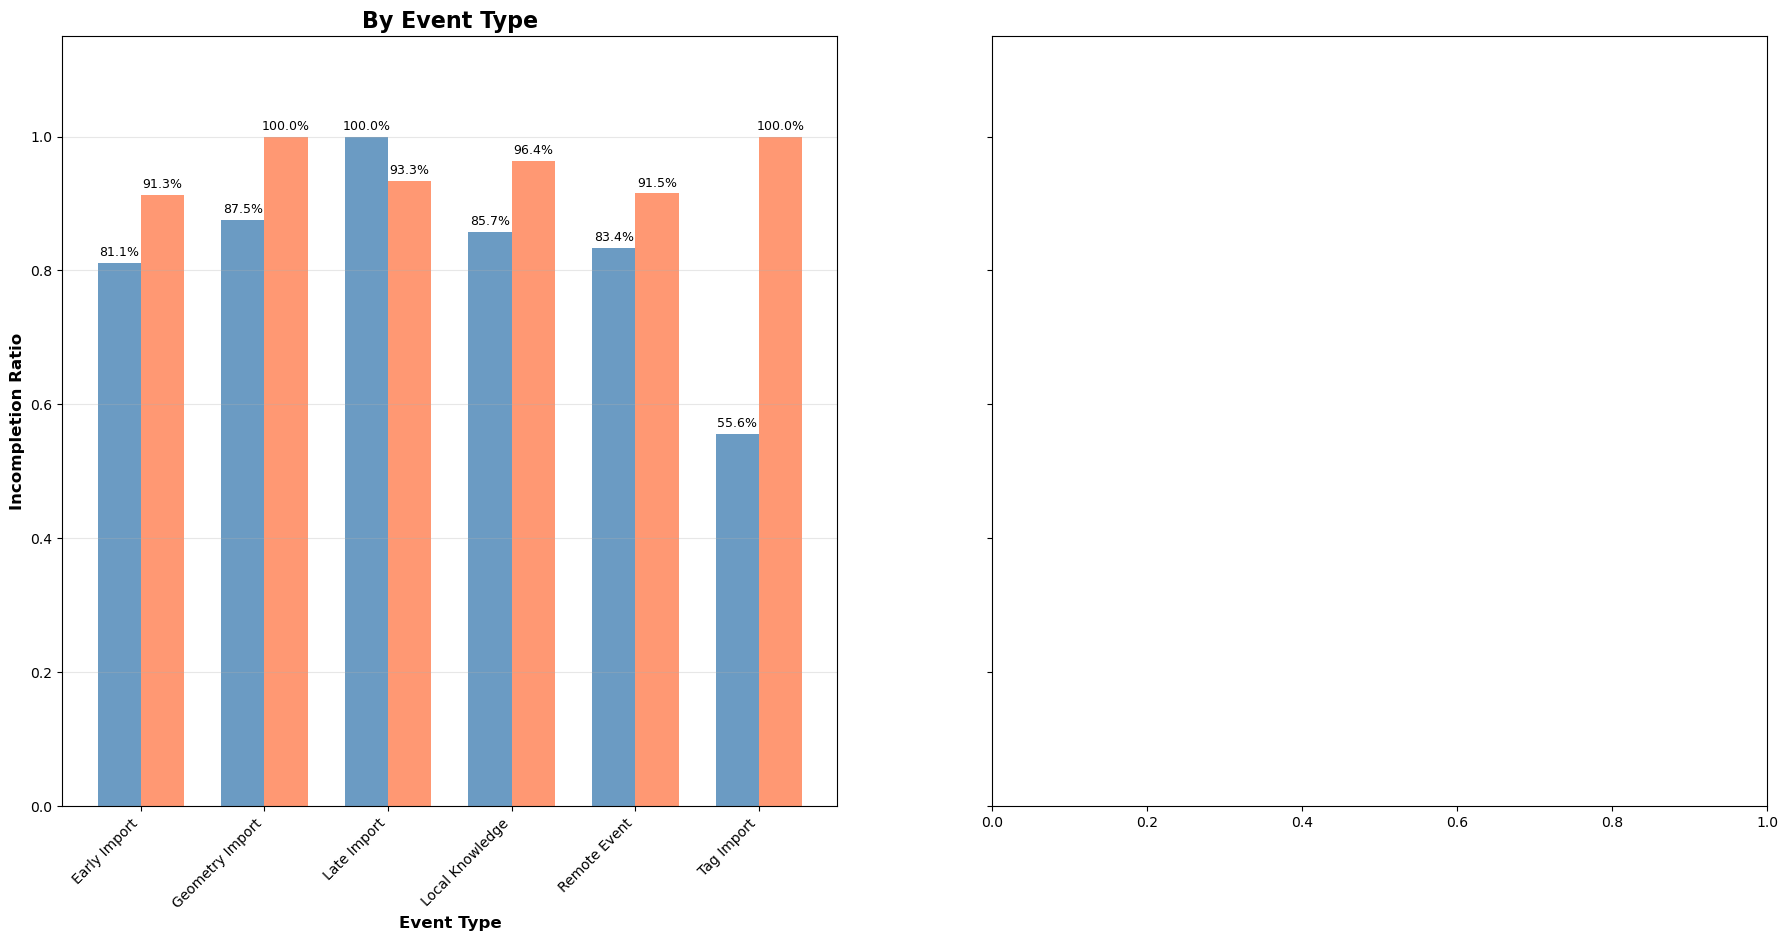

In [61]:
# Prepare data for plotting by event type
# Rename events for cleaner plot labels
bld_plot_data = bld_status_by_type.copy()
road_plot_data = road_status_by_type.copy()

bld_plot_data['Event type'] = bld_plot_data['Event type'].replace(label_map)
road_plot_data['Event type'] = road_plot_data['Event type'].replace(label_map)

# Create combined dataframe for plotting
plot_by_event = pd.concat([
    bld_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Buildings'),
    road_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Roads')
], ignore_index=True)

# Create combined area-bin dataframe for plotting
plot_by_area = pd.concat([
    filtered_bld_sum_by_area[['Area bin', 'Incomplete percentage']].assign(Dataset='Buildings'),
    filtered_road_sum_by_area[['Area bin', 'Incomplete percentage']].assign(Dataset='Roads')
], ignore_index=True)

# Build faceted figure with shared title and legend
fig, axes = plt.subplots(ncols=2, figsize=(22, 10), sharey=True)
datasets = ['Buildings', 'Roads']
colors = ['steelblue', 'coral']
bar_width = 0.35

# Plot event type facet
event_types = sorted(bld_plot_data['Event type'].unique())
x_pos_event = np.arange(len(event_types))
for i, dataset in enumerate(datasets):
    data_subset = plot_by_event[plot_by_event['Dataset'] == dataset]
    values = [data_subset.loc[data_subset['Event type'] == event, 'Incomplete percentage'].values[0] if any(data_subset['Event type'] == event) else 0 for event in event_types]
    offset = (i - 0.5) * bar_width
    bars = axes[0].bar(x_pos_event + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0].annotate(f'{height:.1%}',
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 3),
                             textcoords='offset points',
                             ha='center', va='bottom',
                             fontsize=9)

axes[0].set_title('By Event Type', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Event Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Incompletion Ratio', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos_event)
axes[0].set_xticklabels(event_types, rotation=45, ha='right', fontsize=10)
axes[0].set_ylim(0, 1.15)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot area bin facet
area_bins = list(filtered_road_sum_by_area['area_bin'].cat.categories)
x_pos_area = np.arange(len(area_bins))
for i, dataset in enumerate(datasets):
    data_subset = plot_by_area[plot_by_area['Dataset'] == dataset]
    values = [data_subset.loc[data_subset['Area bin'] == bin, 'Incomplete percentage'].values[0] if any(data_subset['Area bin'] == bin) else 0 for bin in area_bins]
    offset = (i - 0.5) * bar_width
    bars = axes[1].bar(x_pos_area + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[1].annotate(f'{height:.1%}',
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 3),
                             textcoords='offset points',
                             ha='center', va='bottom',
                             fontsize=9)

area_labels = []
for idx, bin in enumerate(area_bins):
    left = 0 if idx == 0 else bin.left
    right = bin.right
    area_labels.append(f'[{left:.0f}, {right:.3f}]')

axes[1].set_title('By Area Bin (8-bin histogram)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Area Bin (Sq. KM)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos_area)
axes[1].set_xticklabels(area_labels, rotation=45, ha='right', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 1.15)

# Shared figure title and subtitle
fig.suptitle('Incomplete Large Scale Events Regions Distributions', fontsize=22, fontweight='bold', y=0.98)
fig.text(0.5, 0.94, 'Buildings vs. Roads Datasets', ha='center', fontsize=16)

# Shared legend below both facets
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12, frameon=False)

plt.subplots_adjust(bottom=0.16, top=0.88, wspace=0.25)
plt.show()
